<a href="https://colab.research.google.com/github/ashwinitadkale/machine_learning/blob/main/time_series_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
!pip install mplfinance
import yfinance as yf
from scipy import stats
import matplotlib.pyplot as plt
import mplfinance as mpf
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA

In [26]:
apple = yf.Ticker("AAPL")
apple_data = apple.history(start="2010-01-01", end="2021-01-01")

In [27]:
apple_data.isnull().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0
Dividends,0
Stock Splits,0


In [28]:
apple_data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2010-01-04 00:00:00-05:00,6.395004,6.427064,6.363543,6.412383,493729600,0.0,0.0
2010-01-05 00:00:00-05:00,6.430061,6.459724,6.389610,6.423469,601904800,0.0,0.0
2010-01-06 00:00:00-05:00,6.423470,6.448939,6.314704,6.321296,552160000,0.0,0.0
2010-01-07 00:00:00-05:00,6.344666,6.352156,6.263765,6.309608,477131200,0.0,0.0
2010-01-08 00:00:00-05:00,6.301221,6.352159,6.264068,6.351559,447610800,0.0,0.0


In [29]:
clean_data = apple_data.dropna()

In [30]:
filled_data = apple_data.fillna(method="ffill")

/tmp/ipykernel_6200/3990797322.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  filled_data = apple_data.fillna(method="ffill")


In [31]:
imputed_data = apple_data.fillna(apple_data.mean())

In [38]:
z_scores = zscore(apple_data["Close"])
filtered_data = apple_data[abs(z_scores) < 3]

In [39]:
Q1 = apple_data["Close"].quantile(0.25)
Q3 = apple_data["Close"].quantile(0.75)
IQR = Q3 - Q1

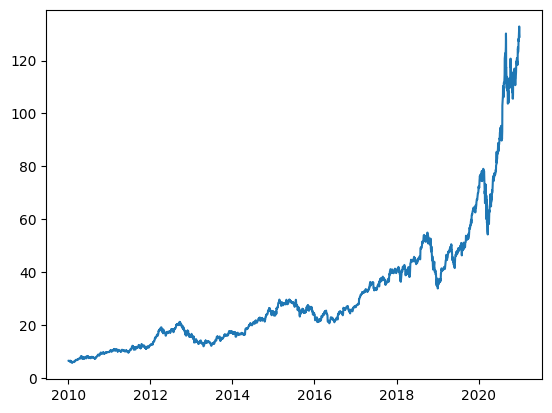

In [41]:
plt.plot(apple_data.index, apple_data["Close"])

/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


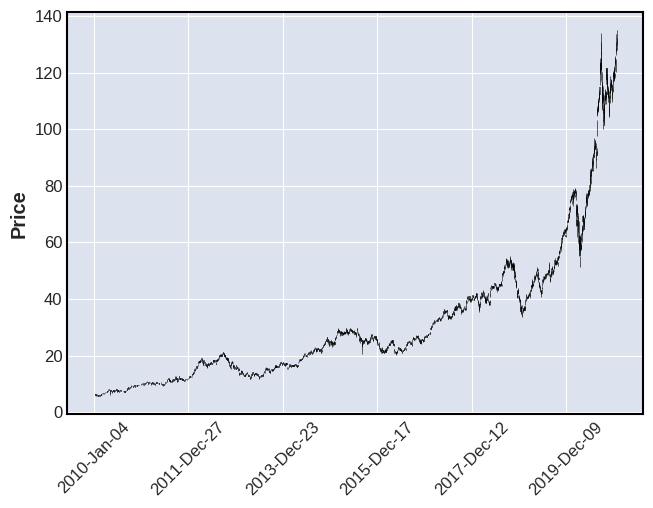

In [45]:
mpf.plot(apple_data, type="candlestick")

<Axes: >

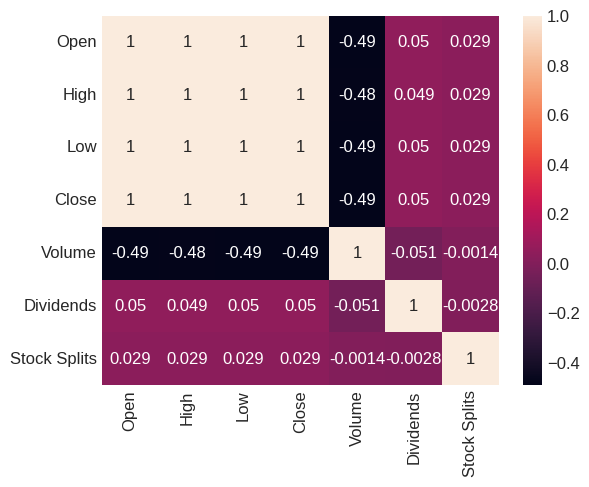

In [48]:
correlation_matrix = apple_data.corr()
sns.heatmap(correlation_matrix, annot=True)

In [49]:
apple_data.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,2769.000000,2769.000000,2769.000000,2769.000000,2.769000e+03,2769.000000,2769.000000
mean,31.224989,31.550729,30.899574,31.238049,2.866162e+08,0.001815,0.003973
std,24.350784,24.679910,24.014436,24.361712,2.289459e+08,0.016744,0.153189
min,5.763984,5.872749,5.700463,5.754397,4.544800e+07,0.000000,0.000000
25%,15.003484,15.169538,14.888312,15.045027,1.211120e+08,0.000000,0.000000
50%,24.363287,24.613835,24.075362,24.296839,2.029972e+08,0.000000,0.000000
75%,40.491995,40.839976,40.243330,40.510788,3.890376e+08,0.000000,0.000000
max,134.259471,134.979143,130.651332,132.936813,1.880998e+09,0.205000,7.000000


In [50]:
before_event = apple_data.loc[apple_data.index < "2020-01-01", "Close"]
after_event = apple_data.loc[apple_data.index >= "2020-01-01", "Close"]

t_statistic, p_value = stats.ttest_ind(before_event, after_event)

In [51]:
X = apple_data[["Volume"]]
y = apple_data["Close"]

In [54]:
model = ARIMA(apple_data["Close"], order=(1, 0, 0))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [55]:
results=model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


In [61]:

predictions = results.forecast(steps=5)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [62]:
print(predictions)

2769    129.037653
2770    129.028675
2771    129.019699
2772    129.010723
2773    129.001748
Name: predicted_mean, dtype: float64
